Dataset loaded successfully!
Shape: (36520, 16)
Random Forest → R²: 0.9759, RMSE: 4.01, MAE: 2.33
Gradient Boosting → R²: 0.9162, RMSE: 7.48, MAE: 5.61
Linear Regression → R²: 0.6759, RMSE: 14.70, MAE: 10.72

✅ Best Model Selected: Random Forest (R² = 0.9759)
✅ Best model saved as 'best_crop_yield_model.pkl'


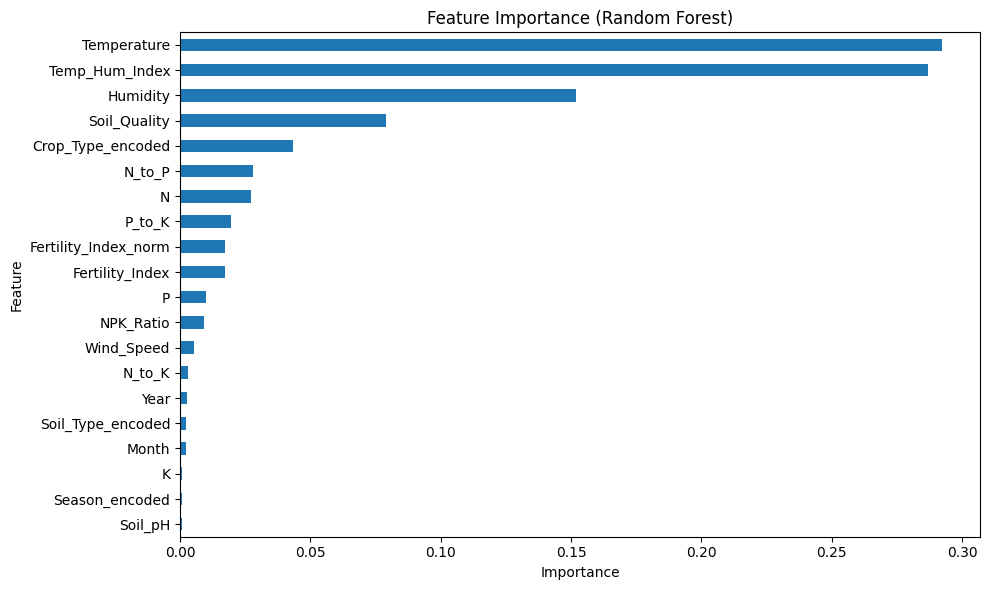

In [1]:
# -------------------- 🌾 Crop Yield ML Pipeline with Model Selection --------------------

# 1️⃣ Import libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import joblib

# -------------------- 2️⃣ Load dataset --------------------
df = pd.read_csv("crop_yield_preprocessed.csv")
print("Dataset loaded successfully!")
print("Shape:", df.shape)

# -------------------- 3️⃣ Feature Engineering --------------------
df['N_to_P'] = df['N'] / (df['P'] + 1e-5)
df['N_to_K'] = df['N'] / (df['K'] + 1e-5)
df['P_to_K'] = df['P'] / (df['K'] + 1e-5)
df['Temp_Hum_Index'] = df['Temperature'] * df['Humidity']
df['Fertility_Index_norm'] = df['Fertility_Index'] / df['Fertility_Index'].max()

# Encode categorical features
le_crop = LabelEncoder()
df['Crop_Type_encoded'] = le_crop.fit_transform(df['Crop_Type'])

le_soil = LabelEncoder()
df['Soil_Type_encoded'] = le_soil.fit_transform(df['Soil_Type'])

le_season = LabelEncoder()
df['Season_encoded'] = le_season.fit_transform(df['Season'])

# Scale numerical features
numerical_cols = [
    'Soil_pH','Temperature','Humidity','Wind_Speed',
    'N','P','K','Soil_Quality','NPK_Ratio','Fertility_Index',
    'N_to_P','N_to_K','P_to_K','Temp_Hum_Index'
]
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# -------------------- 4️⃣ Split dataset --------------------
X = df.drop(['Crop_Yield','Crop_Type','Soil_Type','Season'], axis=1)
y = df['Crop_Yield']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------- 5️⃣ Train Multiple Models --------------------
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

results = []
best_r2 = -np.inf
best_model_name = None
best_model = None

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({
        "Model": name, "MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2
    })
    print(f"{name} → R²: {r2:.4f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}")
    if r2 > best_r2:
        best_r2 = r2
        best_model = model
        best_model_name = name

print(f"\n✅ Best Model Selected: {best_model_name} (R² = {best_r2:.4f})")

# -------------------- 6️⃣ Save Best Model --------------------
joblib.dump(best_model, "best_crop_yield_model.pkl")
print("✅ Best model saved as 'best_crop_yield_model.pkl'")

# -------------------- 7️⃣ Feature Importance (if tree-based) --------------------
if best_model_name in ["Random Forest", "Gradient Boosting"]:
    feat_importances = pd.Series(best_model.feature_importances_, index=X.columns)
    feat_importances.sort_values().plot(kind='barh', figsize=(10,6))
    plt.title(f"Feature Importance ({best_model_name})")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()
